# SENTINEL-WM  |  Phase 1 - Data Pre-processing

Input : `unified_*_labeled.csv` (produced by `extractor.py` + `test1.ipynb`).

Output: `artifacts/clean_flows.parquet` - one tidy row per flow with

* Tier 1 (flow) + Tier 2 (packet) numeric columns, `inf`/`NaN` removed,
* a normalised `Label` -> `attack_family` -> `is_attack`,
* `flow_start_epoch` as the single time axis and a `day` column,
* identity columns kept for windowing **but tagged so no model ever sees a raw IP**.

All logic lives in `preprocessing.py`; this notebook just drives and inspects it.

In [1]:
# bootstrap: make the sentinel_wm package importable without pip install
import sys, pathlib
_root = pathlib.Path.cwd()
_root = _root if (_root / 'sentinel_wm').is_dir() else _root.parent
if str(_root) not in sys.path: sys.path.insert(0, str(_root))

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sentinel_wm import config as C, preprocessing as P
pd.set_option('display.max_columns', 40)
C.RAW_FLOW_CSVS

['C:\\Users\\chall\\OneDrive\\Desktop\\SIH\\data\\unified_Wednesday-WorkingHours_labeled.csv']

## 1.1  Load one raw day file and look at it

In [3]:
raw = pd.read_csv(C.RAW_FLOW_CSVS[0], low_memory=False)
print(raw.shape)
raw['Label'].value_counts()

(692465, 126)


BENIGN              439802
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5794
DoS Slowhttptest      5492
Heartbleed              11
Name: Label, dtype: int64

### The known CIC-IDS-2017 quirks we have to fix
* `Flow Bytes/s`, `Flow Packets/s` contain `Infinity`/`NaN` for zero-duration flows
  (the extractor reproduces this bug on purpose).
* boolean fragment columns must become numeric,
* label strings differ across day files (en-dash vs hyphen, casing).

In [4]:
rate = raw[['Flow Bytes/s','Flow Packets/s']].replace([np.inf,-np.inf], np.nan)
print('non-finite rate cells :', int(rate.isna().sum().sum()))
print('dtypes of frag flags  :', raw[['frag_more_flag_present','frag_dont_flag_present']].dtypes.to_dict())

non-finite rate cells : 2594
dtypes of frag flags  : {'frag_more_flag_present': dtype('bool'), 'frag_dont_flag_present': dtype('bool')}


## 1.2  Run the cleaner

In [5]:
clean = P.clean_flow_frame(raw, verbose=True)

  cleaned 692,465 -> 692,465 rows | 97 numeric model cols | 2,594 inf/NaN cells zero-filled
  family distribution:
BENIGN              439802
    DoS Hulk            231073
    DoS GoldenEye        10293
    DoS slowloris         5794
    DoS Slowhttptest      5492
    Heartbleed              11


## 1.3  Feature tiers (locked schema from `config.py`)
The tiers are what make the pipeline auditable - every column has a known origin.

In [6]:
for name, cols in [('IDENTITY (not model input)', C.IDENTITY_COLS),
                   ('TIER 1  flow  (CSV)',        C.TIER1_FLOW_COLS),
                   ('TIER 2  packet (PCAP)',      C.TIER2_PACKET_COLS),
                   ('TIER 4  metadata (excluded)',C.METADATA_COLS)]:
    present = [c for c in cols if c in clean.columns]
    print(f'{name:32s} {len(present):3d} cols  e.g. {present[:4]}')

IDENTITY (not model input)         7 cols  e.g. ['Flow ID', 'Source IP', 'Destination IP', 'Source Port']
TIER 1  flow  (CSV)               63 cols  e.g. ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets']
TIER 2  packet (PCAP)             26 cols  e.g. ['pkt_ttl_mean', 'pkt_ttl_std', 'pkt_ttl_min', 'pkt_ttl_max']
TIER 4  metadata (excluded)       21 cols  e.g. ['source_file', 'profile', 't_min', 'timestamp_window']


## 1.4  Persist the whole corpus
`load_and_clean()` concatenates every file in `C.RAW_FLOW_CSVS`, sorts by
`(day, flow_start_epoch)` and writes the parquet the next phase reads.

In [7]:
flows = P.load_and_clean(verbose=True)
flows[['day','flow_start_epoch','attack_family','is_attack']].head()

[load] unified_Wednesday-WorkingHours_labeled.csv


  cleaned 692,465 -> 692,465 rows | 97 numeric model cols | 2,594 inf/NaN cells zero-filled
  family distribution:
BENIGN              439802
    DoS Hulk            231073
    DoS GoldenEye        10293
    DoS slowloris         5794
    DoS Slowhttptest      5492
    Heartbleed              11


[save] C:\Users\chall\OneDrive\Desktop\SIH\artifacts\clean_flows.parquet  (692,465 rows, 129 cols)
[days] ['Wednesday']


,day,flow_start_epoch,attack_family,is_attack
0,Wednesday,1.499255e+09,BENIGN,0
1,Wednesday,1.499255e+09,BENIGN,0
2,Wednesday,1.499255e+09,BENIGN,0
3,Wednesday,1.499255e+09,BENIGN,0
4,Wednesday,1.499255e+09,BENIGN,0


## 1.5  Sanity plot - attack flows over the day

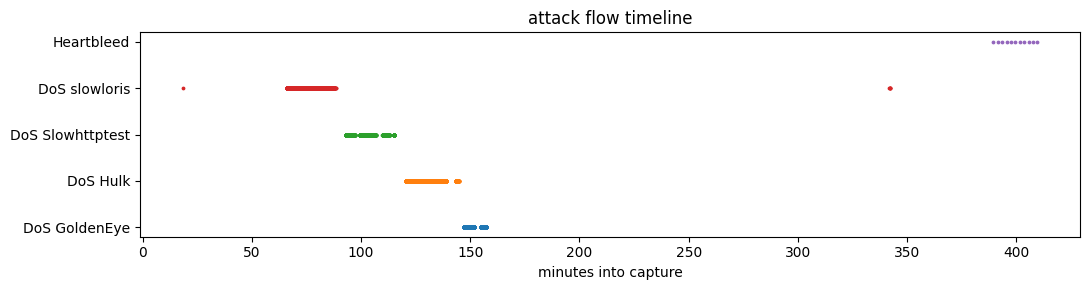

In [8]:
g = flows.copy()
g['min'] = (g['flow_start_epoch'] - g['flow_start_epoch'].min()) / 60
fig, ax = plt.subplots(figsize=(11,3))
for fam, sub in g[g.is_attack==1].groupby('attack_family'):
    ax.scatter(sub['min'], [fam]*len(sub), s=3)
ax.set_xlabel('minutes into capture'); ax.set_title('attack flow timeline'); plt.tight_layout()

---
Next: **`sequence_gen.ipynb`** - aggregate these flows into 10-second network
state windows, derive progression states + ATT&CK phases, and cut sequences.